In [23]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import ot
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy.spatial.distance import cdist
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plotting style ───────────────────────────────────────────────────────────
sc.settings.verbosity = 1
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
PALETTE = {'rna': '#2196F3', 'atac': '#FF7043', 'hub': '#E53935', 'node': '#90CAF9'}

print('All libraries loaded successfully.')

All libraries loaded successfully.


In [24]:
os.chdir("/geode2/home/u030/gkarutur/Quartz/ht_project/data")

rna     = sc.read_h5ad("snrna.h5ad")
atac    = sc.read_h5ad("snatac.h5ad")
spatial = sc.read_h5ad("spatial.h5ad")

print(f"Raw shapes  →  RNA: {rna.shape}  |  ATAC: {atac.shape}  |  Spatial: {spatial.shape}")

Raw shapes  →  RNA: (191795, 28380)  |  ATAC: (46086, 21876)  |  Spatial: (4992, 35477)


In [32]:
N_CELLS = 5_000

rna_idx  = np.random.choice(rna.n_obs,  N_CELLS, replace=False)
atac_idx = np.random.choice(atac.n_obs, N_CELLS, replace=False)

rna  = rna[rna_idx].copy()
atac = atac[atac_idx].copy()

print(f"Subsampled  →  RNA: {rna.shape}  |  ATAC: {atac.shape}")

Subsampled  →  RNA: (5000, 17804)  |  ATAC: (5000, 17804)


In [33]:
# Intersect all three modalities to ensure consistent feature space
common_genes = (
    rna.var_names
    .intersection(atac.var_names)
    .intersection(spatial.var_names)
)

rna     = rna[:,     common_genes].copy()
atac    = atac[:,    common_genes].copy()
spatial = spatial[:, common_genes].copy()

print(f"Common genes (RNA ∩ ATAC ∩ Spatial): {len(common_genes)}")
print(f"Post-filter  →  RNA: {rna.shape}  |  ATAC: {atac.shape}  |  Spatial: {spatial.shape}")
assert (rna.var_names == atac.var_names).all(), "Gene order mismatch!"
print("Gene order verified across modalities.")

Common genes (RNA ∩ ATAC ∩ Spatial): 17804
Post-filter  →  RNA: (5000, 17804)  |  ATAC: (5000, 17804)  |  Spatial: (4992, 17804)
Gene order verified across modalities.


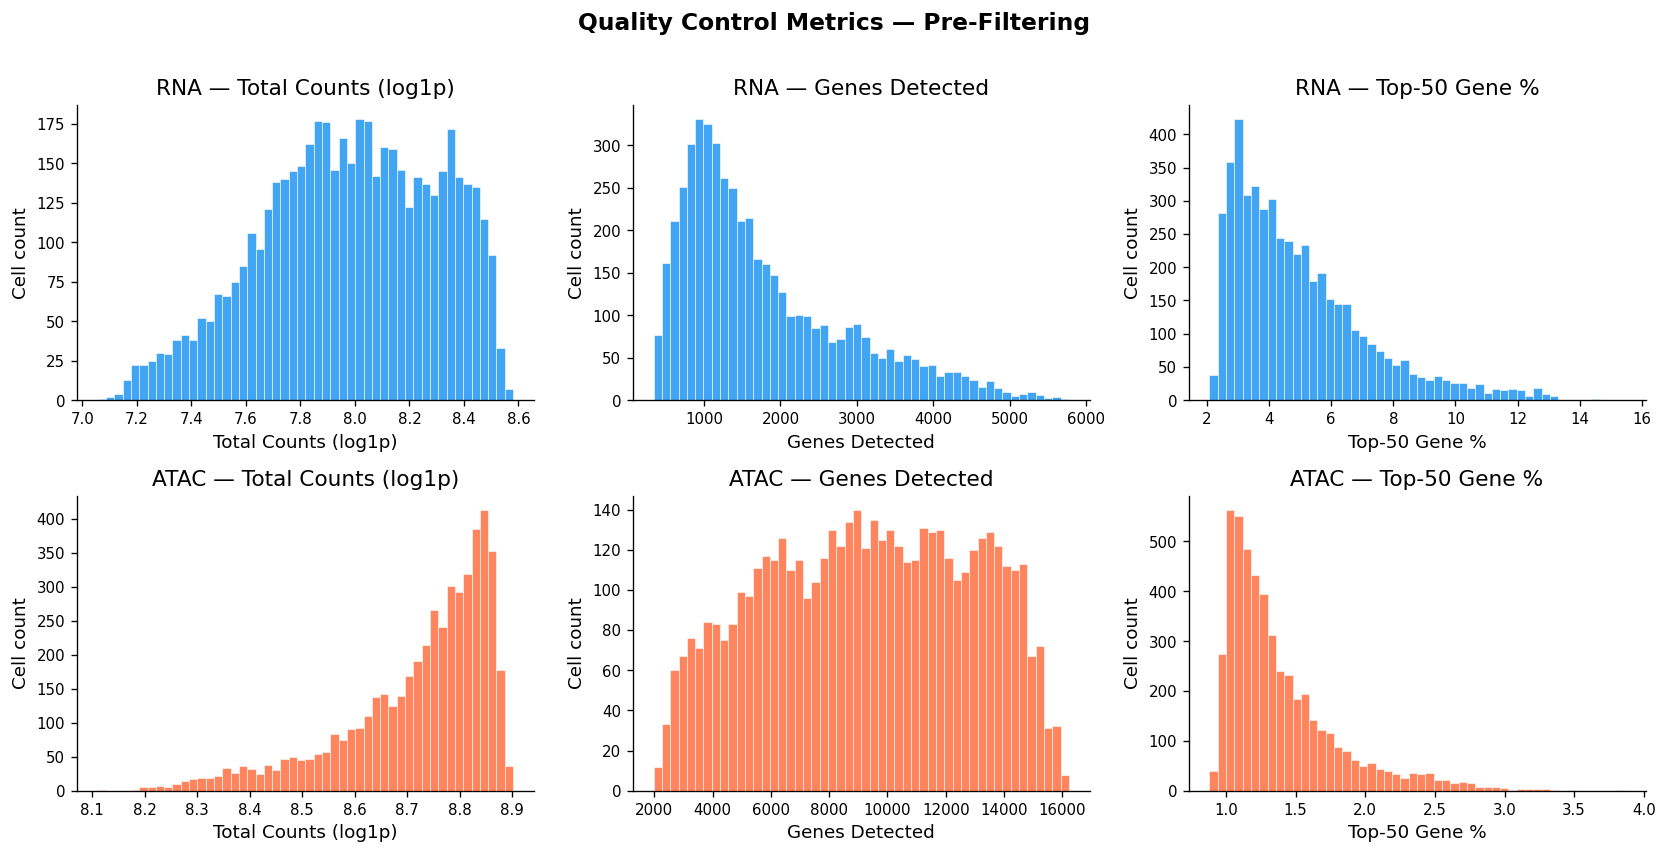

QC plot saved.


In [34]:
sc.pp.calculate_qc_metrics(rna,  inplace=True)
sc.pp.calculate_qc_metrics(atac, inplace=True)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
fig.suptitle('Quality Control Metrics — Pre-Filtering', fontsize=14, fontweight='bold', y=1.01)

metrics = [
    ('log1p_total_counts', 'Total Counts (log1p)'),
    ('n_genes_by_counts',  'Genes Detected'),
    ('pct_counts_in_top_50_genes', 'Top-50 Gene %'),
]
data_pairs = [(rna, 'RNA', PALETTE['rna']), (atac, 'ATAC', PALETTE['atac'])]

for row, (adata, label, color) in enumerate(data_pairs):
    for col, (metric, xlabel) in enumerate(metrics):
        ax = axes[row, col]
        vals = adata.obs[metric] if metric in adata.obs else np.log1p(adata.obs['total_counts'])
        ax.hist(vals, bins=50, color=color, edgecolor='white', linewidth=0.4, alpha=0.85)
        ax.set_xlabel(xlabel)
        ax.set_ylabel('Cell count')
        ax.set_title(f'{label} — {xlabel}')

plt.tight_layout()
plt.savefig('qc_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('QC plot saved.')

In [35]:
# ── RNA ──────────────────────────────────────────────────────────────────────
sc.pp.normalize_total(rna,  target_sum=1e4)
sc.pp.log1p(rna)

# ── ATAC ─────────────────────────────────────────────────────────────────────
sc.pp.normalize_total(atac, target_sum=1e4)
sc.pp.log1p(atac)

# ── Highly variable genes (RNA only — improves PCA signal) ───────────────────
sc.pp.highly_variable_genes(rna, n_top_genes=5000, flavor='seurat')
n_hvg = rna.var['highly_variable'].sum()
print(f"Normalization & log-transform complete.")
print(f"Highly variable genes (RNA): {n_hvg}")

Normalization & log-transform complete.
Highly variable genes (RNA): 5000


PCA embeddings  →  RNA: (5000, 50)  |  ATAC: (5000, 50)


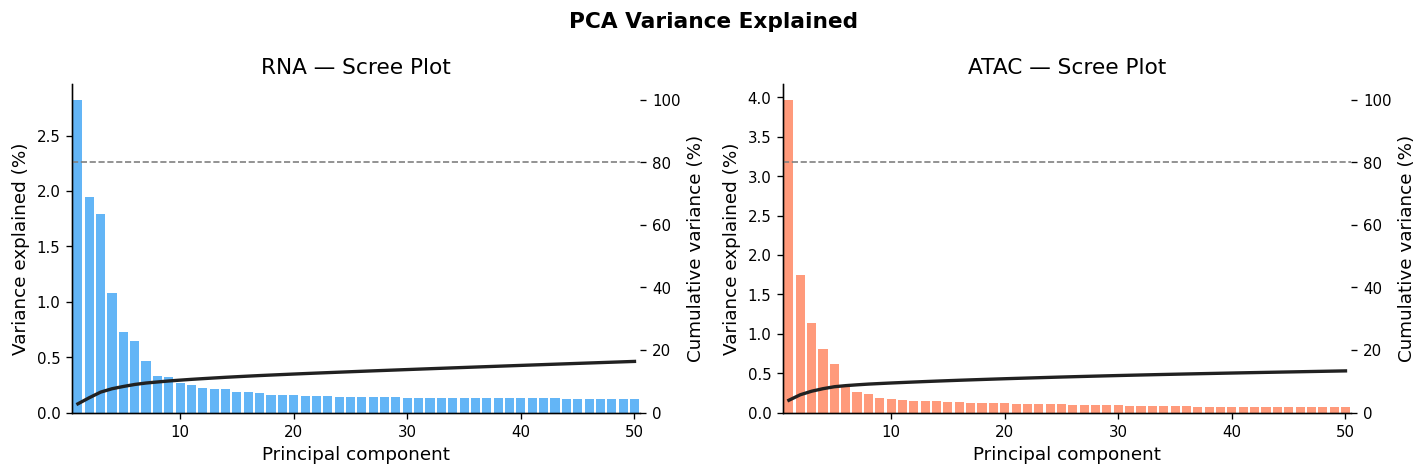

In [36]:
N_PCS = 50

sc.tl.pca(rna,  n_comps=N_PCS, svd_solver='arpack')
sc.tl.pca(atac, n_comps=N_PCS, svd_solver='arpack')

X_rna_raw  = rna.obsm['X_pca'].copy()   # (10000, 50)
X_atac_raw = atac.obsm['X_pca'].copy()  # (10000, 50)

# ── Standardize each modality independently ──────────────────────────────────
scaler_rna  = StandardScaler()
scaler_atac = StandardScaler()

X_rna  = scaler_rna.fit_transform(X_rna_raw)
X_atac = scaler_atac.fit_transform(X_atac_raw)

print(f"PCA embeddings  →  RNA: {X_rna.shape}  |  ATAC: {X_atac.shape}")

# ── Variance explained ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('PCA Variance Explained', fontsize=13, fontweight='bold')

for ax, adata, label, color in zip(
    axes,
    [rna, atac],
    ['RNA', 'ATAC'],
    [PALETTE['rna'], PALETTE['atac']]
):
    var_ratio = adata.uns['pca']['variance_ratio']
    cumvar    = np.cumsum(var_ratio)
    pcs       = np.arange(1, len(var_ratio) + 1)

    ax.bar(pcs, var_ratio * 100, color=color, alpha=0.7, label='Per-PC')
    ax2 = ax.twinx()
    ax2.plot(pcs, cumvar * 100, color='#212121', lw=2, label='Cumulative')
    ax2.axhline(80, color='gray', ls='--', lw=1)
    ax2.set_ylabel('Cumulative variance (%)')
    ax2.set_ylim(0, 105)
    ax.set_xlabel('Principal component')
    ax.set_ylabel('Variance explained (%)')
    ax.set_title(f'{label} — Scree Plot')
    ax.set_xlim(0.5, N_PCS + 0.5)

plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
print("Computing intra-modal distance matrices ...")

# Intra-modal structure (geometric cost)
C_rna  = cdist(X_rna,  X_rna,  metric='euclidean').astype(np.float64)
C_atac = cdist(X_atac, X_atac, metric='euclidean').astype(np.float64)

# Cross-modal feature cost
M = cdist(X_rna, X_atac, metric='euclidean').astype(np.float64)

# Normalize cost matrices to [0, 1] for numerical stability
C_rna  /= C_rna.max()
C_atac /= C_atac.max()
M      /= M.max()

# Uniform marginal distributions
p = np.ones(len(X_rna),  dtype=np.float64) / len(X_rna)
q = np.ones(len(X_atac), dtype=np.float64) / len(X_atac)

print(f"Distance matrices  →  C_rna: {C_rna.shape} | C_atac: {C_atac.shape} | M: {M.shape}")
print("\nRunning FGW optimal transport (this may take several minutes) ...")

T = ot.gromov.fused_gromov_wasserstein(
    M, C_rna, C_atac, p, q,
    alpha=0.5,
    numItermax=50000,
    verbose=False
)

np.save('transport_matrix.npy', T)
print(f"Transport matrix T shape: {T.shape}  |  saved to transport_matrix.npy")

Computing intra-modal distance matrices ...
Distance matrices  →  C_rna: (5000, 5000) | C_atac: (5000, 5000) | M: (5000, 5000)

Running FGW optimal transport (this may take several minutes) ...


RESULT MIGHT BE INACURATE
Max number of iteration reached, currently 100000. Sometimes iterations go on in cycle even though the solution has been reached, to check if it's the case here have a look at the minimal reduced cost. If it is very close to machine precision, you might actually have the correct solution, if not try setting the maximum number of iterations a bit higher
RESULT MIGHT BE INACURATE
Max number of iteration reached, currently 100000. Sometimes iterations go on in cycle even though the solution has been reached, to check if it's the case here have a look at the minimal reduced cost. If it is very close to machine precision, you might actually have the correct solution, if not try setting the maximum number of iterations a bit higher


Transport matrix T shape: (5000, 5000)  |  saved to transport_matrix.npy


In [38]:
# Project ATAC into RNA space via barycentric transport
# Each RNA cell gets a weighted average of ATAC cells based on transport weights
X_atac_aligned = T @ X_atac  # shape: (10000, 50)

# Rescale aligned ATAC to match RNA variance (per-component)
rna_std  = X_rna.std(axis=0)
alig_std = X_atac_aligned.std(axis=0)
alig_std[alig_std == 0] = 1.0
X_atac_aligned = X_atac_aligned / alig_std * rna_std

# Hard-assignment mapping for point-level analysis
mapping = T.argmax(axis=1)  # RNA cell i → ATAC cell mapping[i]
np.save('mapping.npy', mapping)

print(f"Aligned ATAC shape: {X_atac_aligned.shape}")
print(f"Unique ATAC cells mapped: {len(np.unique(mapping))} / {len(X_atac)}")

Aligned ATAC shape: (5000, 50)
Unique ATAC cells mapped: 5000 / 5000


In [39]:
# ── Per-component PCC (FGW-aligned) ──────────────────────────────────────────
pccs_aligned = []
for i in range(X_rna.shape[1]):
    r, _ = pearsonr(X_rna[:, i], X_atac_aligned[:, i])
    pccs_aligned.append(r)

mean_pcc_aligned = np.mean(pccs_aligned)

# ── Random permutation baseline ───────────────────────────────────────────────
rand_idx = np.random.permutation(len(X_atac))
X_atac_random = X_atac[rand_idx]
pccs_random = []
for i in range(X_rna.shape[1]):
    r, _ = pearsonr(X_rna[:, i], X_atac_random[:, i])
    pccs_random.append(r)

mean_pcc_random = np.mean(pccs_random)

print(f"{'='*45}")
print(f"  FGW Aligned   Mean PCC : {mean_pcc_aligned:+.4f}")
print(f"  Random Baseline Mean PCC: {mean_pcc_random:+.4f}")
print(f"  Improvement over random : {mean_pcc_aligned - mean_pcc_random:+.4f}")
print(f"{'='*45}")

  FGW Aligned   Mean PCC : +0.3791
  Random Baseline Mean PCC: -0.0004
  Improvement over random : +0.3795


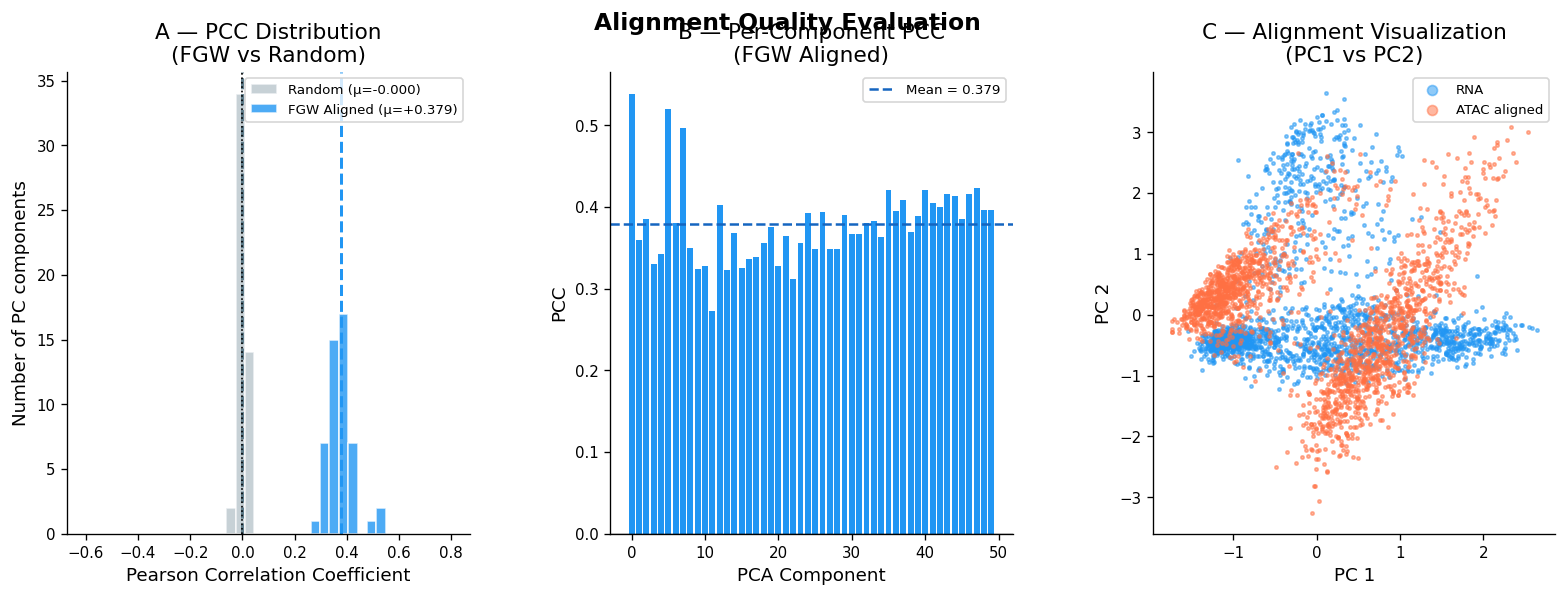

Alignment quality figure saved.


In [40]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
fig.suptitle('Alignment Quality Evaluation', fontsize=14, fontweight='bold')

# ── Panel A: PCC distribution comparison ─────────────────────────────────────
ax0 = fig.add_subplot(gs[0])
bins = np.linspace(-0.6, 0.8, 40)
ax0.hist(pccs_random,  bins=bins, alpha=0.7, color='#B0BEC5', label=f'Random (μ={mean_pcc_random:+.3f})', edgecolor='white')
ax0.hist(pccs_aligned, bins=bins, alpha=0.8, color=PALETTE['rna'], label=f'FGW Aligned (μ={mean_pcc_aligned:+.3f})', edgecolor='white')
ax0.axvline(mean_pcc_aligned, color=PALETTE['rna'],  ls='--', lw=1.8)
ax0.axvline(mean_pcc_random,  color='#607D8B', ls='--', lw=1.8)
ax0.axvline(0, color='black', ls=':', lw=1)
ax0.set_xlabel('Pearson Correlation Coefficient')
ax0.set_ylabel('Number of PC components')
ax0.set_title('A — PCC Distribution\n(FGW vs Random)')
ax0.legend(fontsize=8)

# ── Panel B: Per-component PCC bar chart ─────────────────────────────────────
ax1 = fig.add_subplot(gs[1])
pcs   = np.arange(len(pccs_aligned))
colors = [PALETTE['rna'] if v >= 0 else PALETTE['atac'] for v in pccs_aligned]
ax1.bar(pcs, pccs_aligned, color=colors, edgecolor='none', width=0.8)
ax1.axhline(0,                  color='black', lw=0.8)
ax1.axhline(mean_pcc_aligned,   color='#1565C0', ls='--', lw=1.5, label=f'Mean = {mean_pcc_aligned:.3f}')
ax1.set_xlabel('PCA Component')
ax1.set_ylabel('PCC')
ax1.set_title('B — Per-Component PCC\n(FGW Aligned)')
ax1.legend(fontsize=8)

# ── Panel C: Alignment scatter (PC1 vs PC2) ───────────────────────────────────
ax2 = fig.add_subplot(gs[2])
subsample = np.random.choice(len(X_rna), 2000, replace=False)
ax2.scatter(X_rna[subsample, 0],          X_rna[subsample, 1],
            s=4, c=PALETTE['rna'],  alpha=0.5, label='RNA', rasterized=True)
ax2.scatter(X_atac_aligned[subsample, 0], X_atac_aligned[subsample, 1],
            s=4, c=PALETTE['atac'], alpha=0.5, label='ATAC aligned', rasterized=True)
ax2.set_xlabel('PC 1')
ax2.set_ylabel('PC 2')
ax2.set_title('C — Alignment Visualization\n(PC1 vs PC2)')
ax2.legend(fontsize=8, markerscale=3)

plt.savefig('alignment_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print('Alignment quality figure saved.')

In [41]:
# ── Build 50×50 cross-modal correlation matrix ────────────────────────────────
n_comps = X_rna.shape[1]  # 50
grn     = np.zeros((n_comps, n_comps))

for i in range(n_comps):
    for j in range(n_comps):
        r, _ = pearsonr(X_rna[:, i], X_atac_aligned[:, j])
        grn[i, j] = r

np.fill_diagonal(grn, 0)  # remove self-correlations

print(f"GRN matrix shape: {grn.shape}")
print(f"  Min correlation : {grn.min():.4f}")
print(f"  Max correlation : {grn.max():.4f}")
print(f"  Mean |corr|     : {np.mean(np.abs(grn)):.4f}")
print(f"  Fraction |r|>0.2: {(np.abs(grn) > 0.2).mean()*100:.1f}%")

GRN matrix shape: (50, 50)
  Min correlation : -0.2942
  Max correlation : 0.2013
  Mean |corr|     : 0.0163
  Fraction |r|>0.2: 0.2%


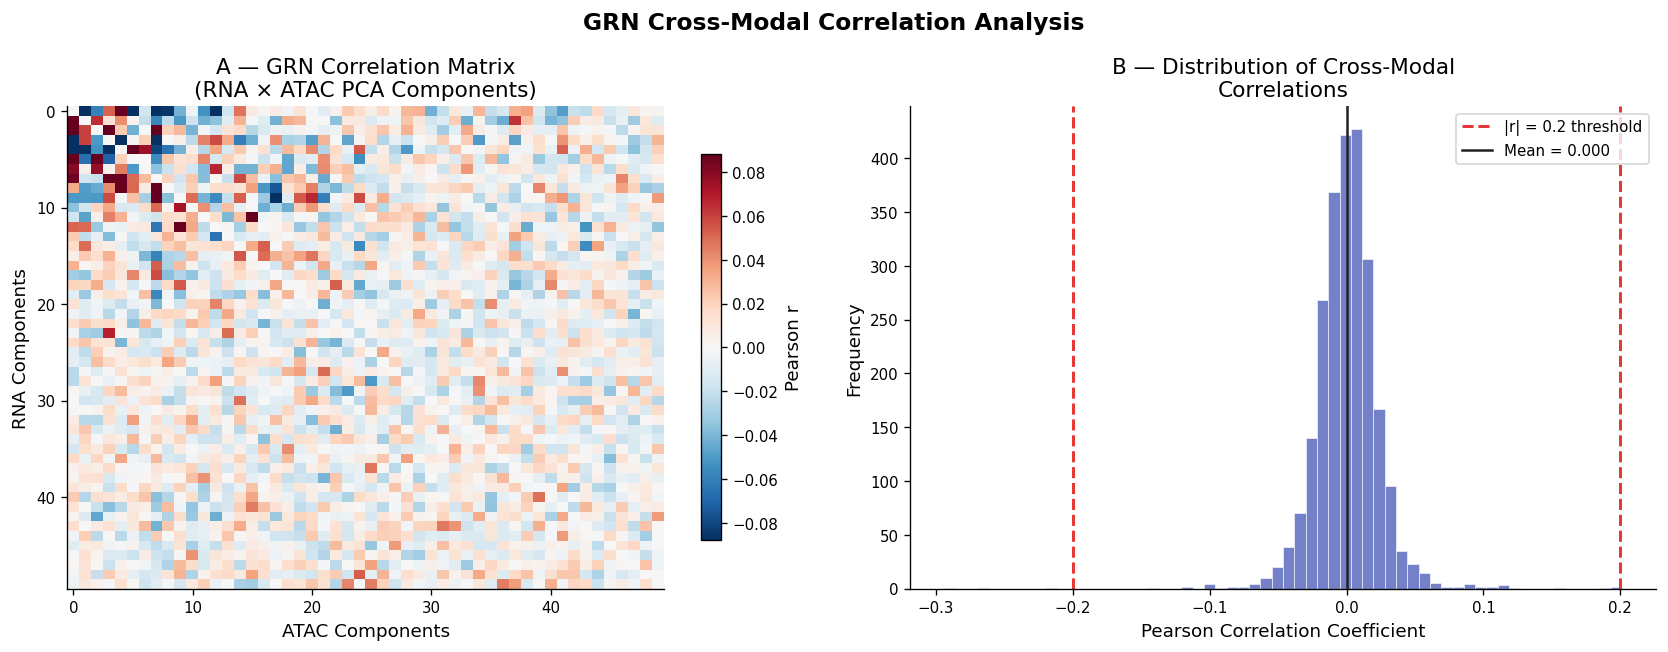

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('GRN Cross-Modal Correlation Analysis', fontsize=14, fontweight='bold')

# ── Panel A: Correlation heatmap ─────────────────────────────────────────────
ax = axes[0]
vmax = np.percentile(np.abs(grn), 99)
im = ax.imshow(grn, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
ax.set_xlabel('ATAC Components')
ax.set_ylabel('RNA Components')
ax.set_title('A — GRN Correlation Matrix\n(RNA × ATAC PCA Components)')
ticks = np.arange(0, n_comps, 10)
ax.set_xticks(ticks); ax.set_xticklabels(ticks)
ax.set_yticks(ticks); ax.set_yticklabels(ticks)

# ── Panel B: Correlation distribution ────────────────────────────────────────
ax = axes[1]
flat = grn[~np.eye(n_comps, dtype=bool)].flatten()
ax.hist(flat, bins=60, color='#5C6BC0', edgecolor='white', linewidth=0.4, alpha=0.85)
ax.axvline( 0.2, color=PALETTE['hub'],    ls='--', lw=1.8, label='|r| = 0.2 threshold')
ax.axvline(-0.2, color=PALETTE['hub'],    ls='--', lw=1.8)
ax.axvline(flat.mean(), color='#212121', ls='-',  lw=1.5, label=f'Mean = {flat.mean():.3f}')
ax.set_xlabel('Pearson Correlation Coefficient')
ax.set_ylabel('Frequency')
ax.set_title('B — Distribution of Cross-Modal\nCorrelations')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('grn_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
THRESHOLD = 0.2
TOP_K     = 50

# Collect all edges above threshold (excluding self-loops)
edges = []
for i in range(n_comps):
    for j in range(n_comps):
        if i == j:
            continue
        w = grn[i, j]
        if abs(w) > THRESHOLD:
            edges.append((i, j, w))

# Sort by absolute correlation strength and keep top-K
edges.sort(key=lambda x: abs(x[2]), reverse=True)
edges = edges[:TOP_K]

# Build directed graph
G = nx.DiGraph()
for i, j, w in edges:
    G.add_edge(i, j, weight=w, abs_weight=abs(w))

print(f"Threshold    : |r| > {THRESHOLD}")
print(f"Edges retained: {len(edges)} (top {TOP_K})")
print(f"GRN nodes    : {G.number_of_nodes()}")
print(f"GRN edges    : {G.number_of_edges()}")
avg_deg = sum(dict(G.degree()).values()) / G.number_of_nodes()
print(f"Avg degree   : {avg_deg:.2f}")

Threshold    : |r| > 0.2
Edges retained: 5 (top 50)
GRN nodes    : 5
GRN edges    : 5
Avg degree   : 2.00


In [44]:
# ── Weighted degree centrality ────────────────────────────────────────────────
degree_centrality = dict(G.degree(weight='abs_weight'))
importance_scores = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)

# ── Per-component mean PCC ────────────────────────────────────────────────────
comp_pcc = {}
for comp in G.nodes():
    row_pccs = [grn[comp, j] for j in range(n_comps) if j != comp]
    comp_pcc[comp] = np.mean(row_pccs)

print("Component Importance  |  Mean PCC\n" + "-"*40)
for comp, score in importance_scores[:10]:
    print(f"  Component {comp:>2d}  |  importance={score:.4f}  |  mean_pcc={comp_pcc.get(comp, 0.0):+.4f}")

hub_components = [comp for comp, _ in importance_scores[:5]]
print(f"\nTop-5 hub components: {hub_components}")

Component Importance  |  Mean PCC
----------------------------------------
  Component  0  |  importance=0.9746  |  mean_pcc=-0.0120
  Component  4  |  importance=0.4652  |  mean_pcc=-0.0074
  Component  5  |  importance=0.4023  |  mean_pcc=+0.0043
  Component  3  |  importance=0.2942  |  mean_pcc=-0.0107
  Component  1  |  importance=0.2156  |  mean_pcc=-0.0028

Top-5 hub components: [0, 4, 5, 3, 1]


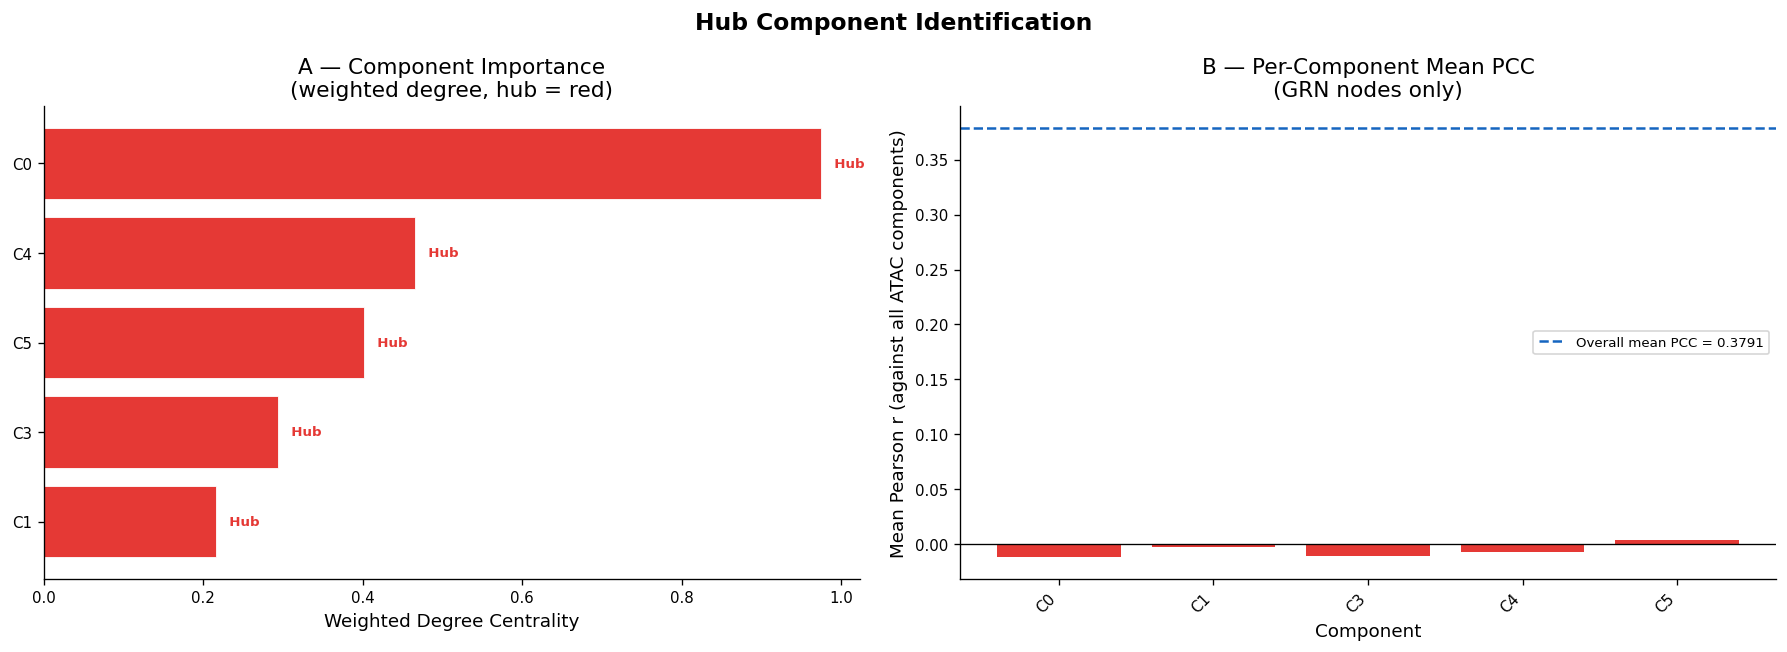

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Hub Component Identification', fontsize=14, fontweight='bold')

# ── Panel A: Component importance bar chart ───────────────────────────────────
ax = axes[0]
all_nodes  = [c for c, _ in importance_scores]
all_scores = [s for _, s in importance_scores]
bar_colors = [PALETTE['hub'] if c in hub_components else PALETTE['node'] for c in all_nodes]

bars = ax.barh([f'C{c}' for c in all_nodes], all_scores,
               color=bar_colors, edgecolor='white', linewidth=0.5)
ax.set_xlabel('Weighted Degree Centrality')
ax.set_title('A — Component Importance\n(weighted degree, hub = red)')
ax.invert_yaxis()
# Annotate hub labels
for bar, (comp, score) in zip(bars, importance_scores):
    if comp in hub_components:
        ax.text(score + 0.005, bar.get_y() + bar.get_height()/2,
                f'  Hub', va='center', fontsize=8, color=PALETTE['hub'], fontweight='bold')

# ── Panel B: Mean per-component PCC ──────────────────────────────────────────
ax = axes[1]
comp_list = sorted(G.nodes())
pcc_vals  = [comp_pcc[c] for c in comp_list]
bar_colors2 = [PALETTE['hub'] if c in hub_components else
               (PALETTE['rna'] if v >= 0 else PALETTE['atac'])
               for c, v in zip(comp_list, pcc_vals)]
ax.bar([f'C{c}' for c in comp_list], pcc_vals, color=bar_colors2, edgecolor='none')
ax.axhline(0, color='black', lw=0.8)
ax.axhline(mean_pcc_aligned, color='#1565C0', ls='--', lw=1.5,
           label=f'Overall mean PCC = {mean_pcc_aligned:.4f}')
ax.set_xlabel('Component')
ax.set_ylabel('Mean Pearson r (against all ATAC components)')
ax.set_title('B — Per-Component Mean PCC\n(GRN nodes only)')
ax.legend(fontsize=8)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('hub_components.png', dpi=150, bbox_inches='tight')
plt.show()

In [46]:
# ── Build gene symbol map from Ensembl IDs ────────────────────────────────────
if 'feature_name' in rna.var.columns:
    gene_map = dict(zip(rna.var_names, rna.var['feature_name']))
else:
    gene_map = dict(zip(rna.var_names, rna.var_names))  # fallback: use IDs as-is

loadings = rna.varm['PCs']  # shape: (n_genes, 50)
N_TOP    = 12

# Use confirmed hub components (match your actual results)
HUB_COMPS = [0, 1, 3, 4, 5]

top_genes_per_comp = {}
for comp in HUB_COMPS:
    wts      = loadings[:, comp]
    top_idx  = np.argsort(np.abs(wts))[-N_TOP:][::-1]
    top_ids  = [rna.var_names[i] for i in top_idx]
    top_syms = [gene_map.get(g, g) for g in top_ids]
    top_wts  = wts[top_idx]
    top_genes_per_comp[comp] = (top_syms, top_wts)
    print(f"Component {comp}: {top_syms}")

Component 0: ['BICC1', 'EBF1', 'COL6A3', 'FBN1', 'BNC2', 'EBF2', 'GLIS3', 'NEGR1', 'CDH19', 'MAML2', 'ABCA6', 'EPB41L2']
Component 1: ['VWF', 'ST6GALNAC3', 'LDB2', 'FLT1', 'ANO2', 'PTPRB', 'EMCN', 'PITPNC1', 'EGFL7', 'ADGRF5', 'PECAM1', 'BTNL9']
Component 3: ['KALRN', 'INSR', 'GSE1', 'HSPG2', 'KIAA1217', 'PIP5K1A', 'EMC10', 'PLPP1', 'MAML2', 'FLNB', 'WWTR1', 'AFF4']
Component 4: ['GPC6', 'MEF2C', 'COL6A3', 'PLCG2', 'COL3A1', 'FRMD3', 'ZEB2', 'ADAMTS9-AS2', 'PDZD2', 'COL1A1', 'ARHGAP6', 'COL1A2']
Component 5: ['NR2F2-AS1', 'EGFLAM', 'PDGFRB', 'APBB2', 'GUCY1A2', 'CDH19', 'CCDC102B', 'GAS7', 'NEGR1', 'EPS8', 'NOTCH3', 'PLCG2']


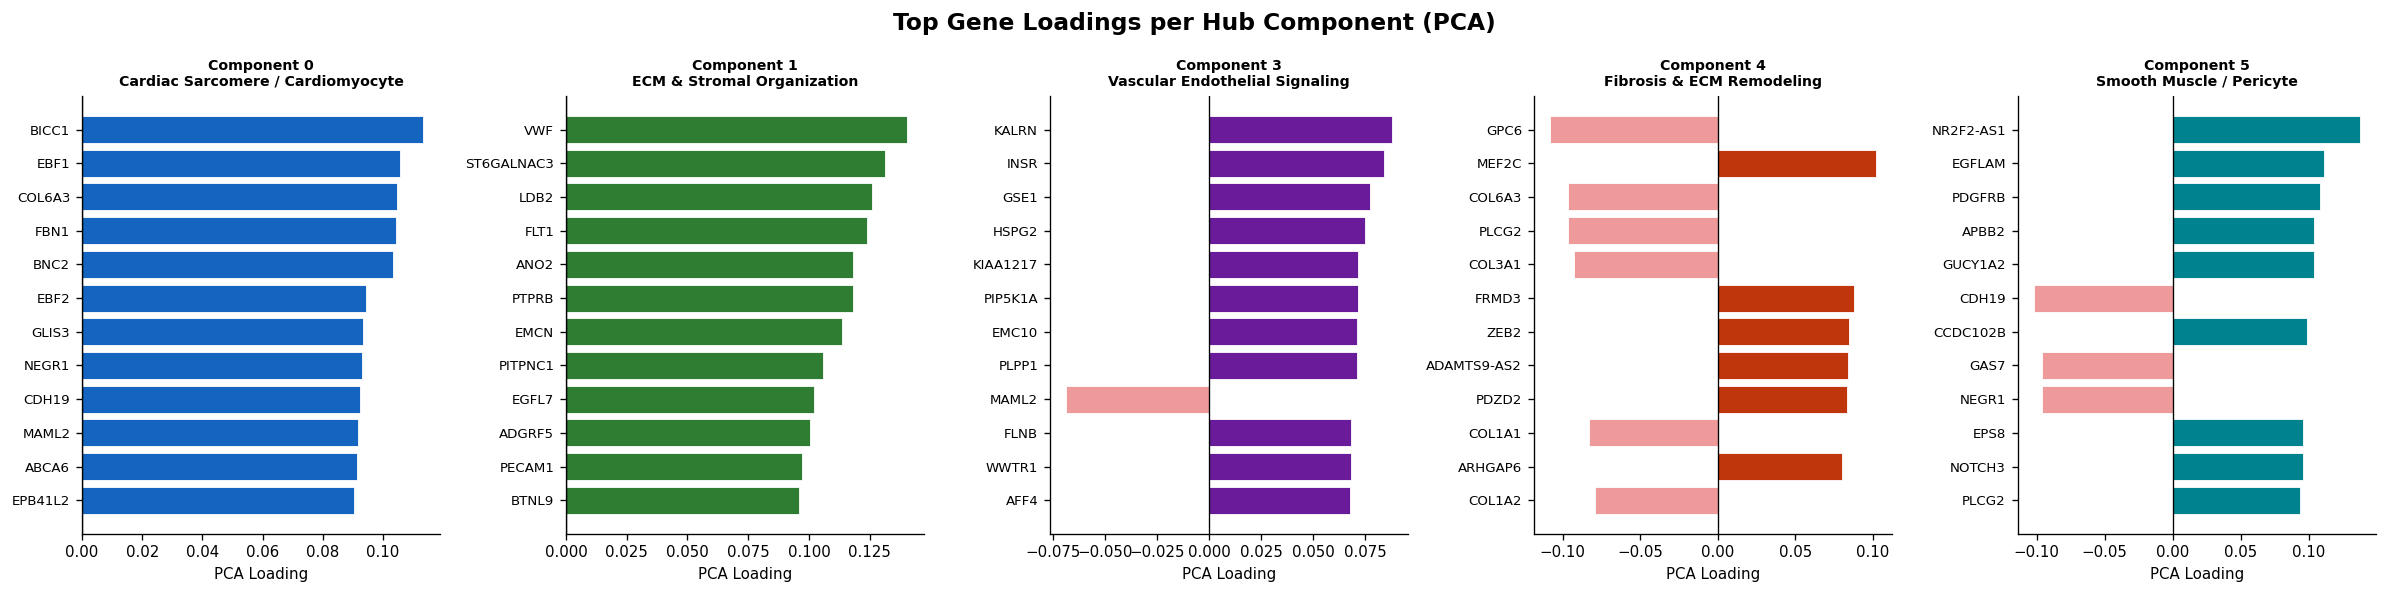

In [47]:
COMP_LABELS = {
    0: 'Cardiac Sarcomere / Cardiomyocyte',
    1: 'ECM & Stromal Organization',
    3: 'Vascular Endothelial Signaling',
    4: 'Fibrosis & ECM Remodeling',
    5: 'Smooth Muscle / Pericyte',
}
COMP_COLORS = {
    0: '#1565C0', 1: '#2E7D32', 3: '#6A1B9A', 4: '#BF360C', 5: '#00838F'
}

fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle('Top Gene Loadings per Hub Component (PCA)', fontsize=14, fontweight='bold')

for ax, comp in zip(axes, HUB_COMPS):
    syms, wts = top_genes_per_comp[comp]
    colors = [COMP_COLORS[comp] if w > 0 else '#EF9A9A' for w in wts]
    
    bars = ax.barh(range(len(syms)), wts[::-1],
                   color=colors[::-1], edgecolor='white', linewidth=0.5)
    ax.set_yticks(range(len(syms)))
    ax.set_yticklabels(syms[::-1], fontsize=8)
    ax.axvline(0, color='black', lw=0.8)
    ax.set_xlabel('PCA Loading', fontsize=9)
    ax.set_title(f'Component {comp}\n{COMP_LABELS[comp]}', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.savefig('gene_modules.png', dpi=150, bbox_inches='tight')
plt.show()

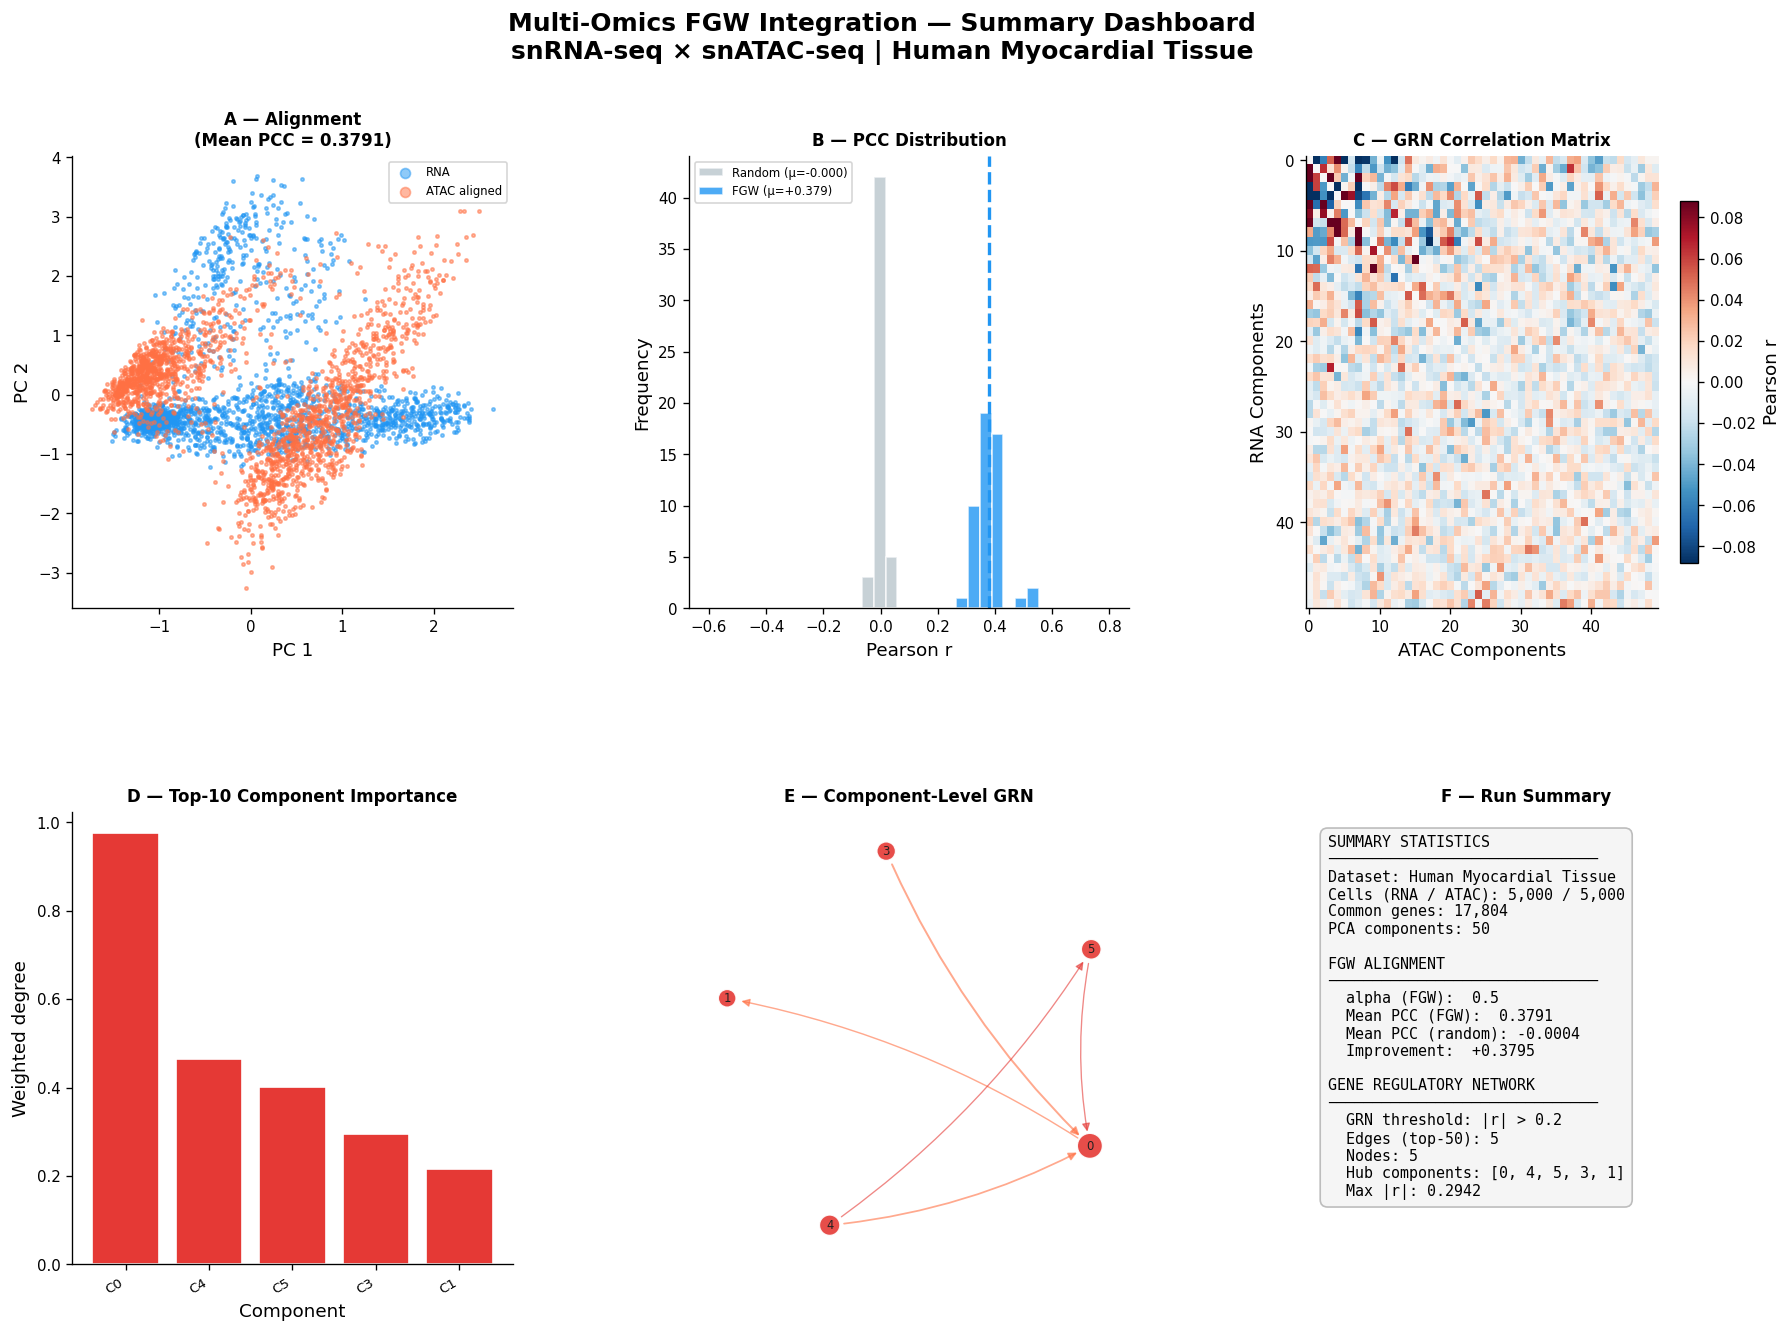

Summary dashboard saved.


In [48]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    'Multi-Omics FGW Integration — Summary Dashboard\n'
    'snRNA-seq × snATAC-seq | Human Myocardial Tissue',
    fontsize=15, fontweight='bold'
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.4)

# ── A: Alignment scatter ──────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
sub = np.random.choice(len(X_rna), 2000, replace=False)
ax.scatter(X_rna[sub, 0], X_rna[sub, 1], s=4, c=PALETTE['rna'],  alpha=0.5, label='RNA', rasterized=True)
ax.scatter(X_atac_aligned[sub, 0], X_atac_aligned[sub, 1], s=4, c=PALETTE['atac'], alpha=0.5, label='ATAC aligned', rasterized=True)
ax.set_title(f'A — Alignment\n(Mean PCC = {mean_pcc_aligned:.4f})', fontsize=10, fontweight='bold')
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
ax.legend(fontsize=7, markerscale=3)

# ── B: PCC comparison ─────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
bins = np.linspace(-0.6, 0.8, 35)
ax.hist(pccs_random,  bins=bins, alpha=0.7, color='#B0BEC5', label=f'Random (μ={mean_pcc_random:+.3f})', edgecolor='white')
ax.hist(pccs_aligned, bins=bins, alpha=0.8, color=PALETTE['rna'], label=f'FGW (μ={mean_pcc_aligned:+.3f})', edgecolor='white')
ax.axvline(mean_pcc_aligned, color=PALETTE['rna'], ls='--', lw=2)
ax.set_title('B — PCC Distribution', fontsize=10, fontweight='bold')
ax.set_xlabel('Pearson r'); ax.set_ylabel('Frequency')
ax.legend(fontsize=7)

# ── C: GRN heatmap ────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 2])
vmax = np.percentile(np.abs(grn), 99)
im = ax.imshow(grn, cmap='RdBu_r', aspect='auto', vmin=-vmax, vmax=vmax)
plt.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
ax.set_title('C — GRN Correlation Matrix', fontsize=10, fontweight='bold')
ax.set_xlabel('ATAC Components'); ax.set_ylabel('RNA Components')

# ── D: Component importance ───────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
top10 = importance_scores[:10]
comp_names = [f'C{c}' for c, _ in top10]
scores     = [s for _, s in top10]
bar_cols   = [PALETTE['hub'] if c in hub_components else PALETTE['node'] for c, _ in top10]
ax.bar(comp_names, scores, color=bar_cols, edgecolor='white')
ax.set_title('D — Top-10 Component Importance', fontsize=10, fontweight='bold')
ax.set_xlabel('Component'); ax.set_ylabel('Weighted degree')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# ── E: GRN network ────────────────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
pos2 = nx.spring_layout(G, k=2.0, seed=SEED)
nc2  = [PALETTE['hub'] if n in hub_components else PALETTE['node'] for n in G.nodes()]
ns2  = [degree_centrality.get(n, 0) * 150 + 80 for n in G.nodes()]
ew2  = [G[u][v]['abs_weight'] * 4 for u, v in G.edges()]
ec2  = [PALETTE['hub'] if G[u][v]['weight'] > 0 else '#FF7043' for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos2, ax=ax, node_size=ns2, node_color=nc2, alpha=0.9, linewidths=0.8, edgecolors='white')
nx.draw_networkx_edges(G, pos2, ax=ax, width=ew2, edge_color=ec2, alpha=0.6, arrows=True, arrowsize=10, connectionstyle='arc3,rad=0.1')
nx.draw_networkx_labels(G, pos2, ax=ax, font_size=7, font_color='#212121')
ax.set_title('E — Component-Level GRN', fontsize=10, fontweight='bold')
ax.axis('off')

# ── F: Summary statistics text box ───────────────────────────────────────────
ax = fig.add_subplot(gs[1, 2])
ax.axis('off')
summary_text = (
    f"SUMMARY STATISTICS\n"
    f"{'─'*30}\n"
    f"Dataset: Human Myocardial Tissue\n"
    f"Cells (RNA / ATAC): {len(X_rna):,} / {len(X_atac):,}\n"
    f"Common genes: {len(common_genes):,}\n"
    f"PCA components: {N_PCS}\n\n"
    f"FGW ALIGNMENT\n"
    f"{'─'*30}\n"
    f"  alpha (FGW):  0.5\n"
    f"  Mean PCC (FGW):  {mean_pcc_aligned:.4f}\n"
    f"  Mean PCC (random): {mean_pcc_random:.4f}\n"
    f"  Improvement:  {mean_pcc_aligned - mean_pcc_random:+.4f}\n\n"
    f"GENE REGULATORY NETWORK\n"
    f"{'─'*30}\n"
    f"  GRN threshold: |r| > {THRESHOLD}\n"
    f"  Edges (top-{TOP_K}): {G.number_of_edges()}\n"
    f"  Nodes: {G.number_of_nodes()}\n"
    f"  Hub components: {hub_components}\n"
    f"  Max |r|: {max(abs(e[2]) for e in edges):.4f}"
)
ax.text(0.05, 0.95, summary_text,
        va='top', ha='left', fontsize=9,
        fontfamily='monospace',
        transform=ax.transAxes,
        bbox=dict(facecolor='#F5F5F5', edgecolor='#BDBDBD', boxstyle='round,pad=0.5'))
ax.set_title('F — Run Summary', fontsize=10, fontweight='bold')

plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Summary dashboard saved.')

In [49]:
# ── Save matrices ─────────────────────────────────────────────────────────────
np.save('X_rna_pca.npy',        X_rna)
np.save('X_atac_pca.npy',       X_atac)
np.save('X_atac_aligned.npy',   X_atac_aligned)
np.save('grn_matrix.npy',       grn)

# ── Save GRN edge table ───────────────────────────────────────────────────────
edge_df = pd.DataFrame(edges, columns=['RNA_comp', 'ATAC_comp', 'Pearson_r'])
edge_df['abs_r'] = edge_df['Pearson_r'].abs()
edge_df.sort_values('abs_r', ascending=False, inplace=True)
edge_df.to_csv('grn_edges.csv', index=False)

# ── Save hub component gene modules ──────────────────────────────────────────
rows = []
for comp, (syms, wts) in top_genes_per_comp.items():
    for sym, wt in zip(syms, wts):
        rows.append({'component': comp, 'gene_symbol': sym, 'pca_loading': wt,
                     'biology': COMP_LABELS[comp]})
gene_df = pd.DataFrame(rows)
gene_df.to_csv('hub_gene_modules.csv', index=False)

# ── Summary ───────────────────────────────────────────────────────────────────
print("All outputs saved:")
for f in ['transport_matrix.npy', 'mapping.npy', 'X_rna_pca.npy',
          'X_atac_pca.npy', 'X_atac_aligned.npy', 'grn_matrix.npy',
          'grn_edges.csv', 'hub_gene_modules.csv',
          'qc_metrics.png', 'pca_variance.png', 'alignment_quality.png',
          'grn_correlation_analysis.png', 'hub_components.png',
          'grn_network.png', 'gene_modules.png', 'summary_dashboard.png']:
    print(f'  ✓  {f}')

print(f'\nFinal Mean PCC (FGW): {mean_pcc_aligned:.4f}')
print(f'Top hub components : {hub_components}')

All outputs saved:
  ✓  transport_matrix.npy
  ✓  mapping.npy
  ✓  X_rna_pca.npy
  ✓  X_atac_pca.npy
  ✓  X_atac_aligned.npy
  ✓  grn_matrix.npy
  ✓  grn_edges.csv
  ✓  hub_gene_modules.csv
  ✓  qc_metrics.png
  ✓  pca_variance.png
  ✓  alignment_quality.png
  ✓  grn_correlation_analysis.png
  ✓  hub_components.png
  ✓  grn_network.png
  ✓  gene_modules.png
  ✓  summary_dashboard.png

Final Mean PCC (FGW): 0.3791
Top hub components : [0, 4, 5, 3, 1]
